# Week 2, Day 1 — Can a Neural Network Predict Anything?

**Before this notebook:** read this article — a plain-language
intro to neural networks (neurons, weights, forward pass, gradient descent).
Nothing here will make sense without that foundation, so if you haven't read it
yet, stop and do that first.

[A Beginner Intro to Neural Networks](https://purnasaigudikandula.medium.com/a-beginner-intro-to-neural-networks-543267bda3c8)

**Today's real question isn't "can a neural network learn."** It obviously can —
you'll see that in five minutes. The real question is: **what does a neural
network actually need in order to learn something, and what happens when it
doesn't have it?**

We'll answer that in three steps, each one harder than the last:

1. A network fits something easy — nothing hidden, no trick.
2. The same network fails, badly, at something that *looks* just as simple.
3. We try it on a real stock's returns and see what actually happens.

By the end, you'll have a real, physical intuition for something most people
are only ever told: *"neural networks need the right kind of input, not just
enough of it."*

In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


## 1. Something an MLP fits easily

Start with the cleanest possible case: `y = x² − 2x + noise`. There's nothing
hidden here — the true answer is a plain function of the input you're given.
If a neural network can't learn this, something is wrong with the network. If
it can, we have our baseline for what "learning is working" looks like.

**One detail worth noticing before you run this:** the train/test split here is
a **random shuffle**, not a chronological cut. That's deliberate, and different
from almost everything else in this program — this is a static function, not a
time series, so there's no real notion of "the future" to protect. Splitting by
time would actually be wrong here; it would just test extrapolation to a
different x-range, not genuine generalization.

In [9]:
torch.manual_seed(0); np.random.seed(0)

x = np.linspace(-3, 3, 800).reshape(-1, 1).astype('float32')
noise = np.random.randn(*x.shape) * 0.3
y = (x**2 - 2*x + noise).astype('float32').ravel()

# random shuffle split -- this is a static function, not a time series
idx = np.random.permutation(len(x))
split = int(len(x) * 0.7)
train_idx, test_idx = idx[:split], idx[split:]
Xtr, ytr = torch.tensor(x[train_idx]), torch.tensor(y[train_idx])
Xte, yte = torch.tensor(x[test_idx]), torch.tensor(y[test_idx])

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = MLP()
opt = torch.optim.Adam(model.parameters(), lr=0.01)
train_hist, test_hist = [], []
for epoch in range(400):
    opt.zero_grad()
    loss = nn.functional.mse_loss(model(Xtr), ytr)
    loss.backward(); 
    opt.step()
    train_hist.append(loss.item())
    test_hist.append(nn.functional.mse_loss(model(Xte), yte).item())

noise_floor = (noise**2).mean()
print(f'final train loss: {train_hist[-1]:.4f}')
print(f'final test loss:  {test_hist[-1]:.4f}')
print(f'theoretical noise floor: {noise_floor:.4f}  (the best any model could ever do)')
print(f'test loss is {test_hist[-1]/noise_floor:.2f}x the noise floor')

final train loss: 0.1070
final test loss:  0.1078
theoretical noise floor: 0.0898  (the best any model could ever do)
test loss is 1.20x the noise floor


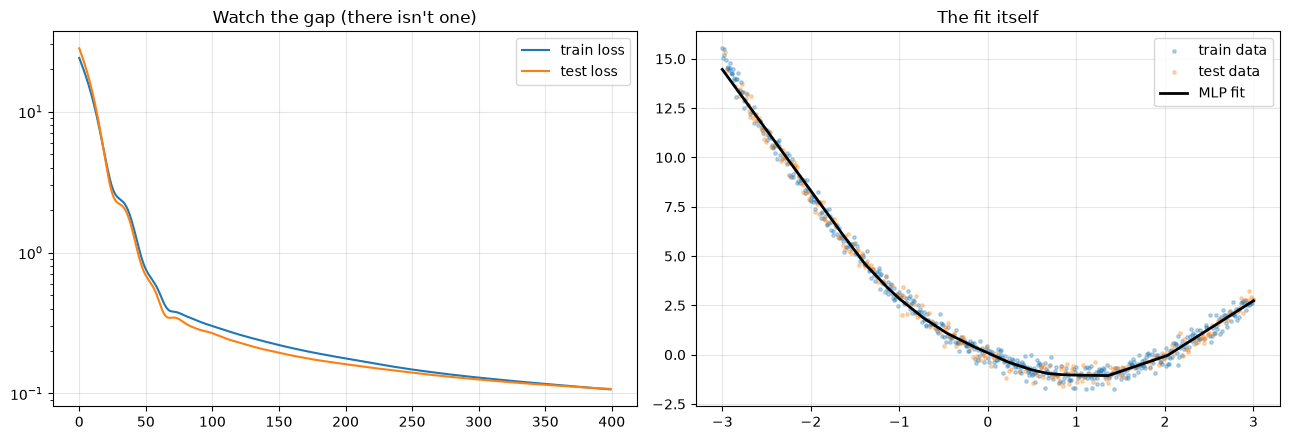

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(train_hist, label='train loss')
axes[0].plot(test_hist, label='test loss')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_title("Watch the gap (there isn't one)")

x_sorted = np.linspace(-3, 3, 300).reshape(-1, 1).astype('float32')
with torch.no_grad():
    y_pred = model(torch.tensor(x_sorted)).numpy()
axes[1].scatter(x[train_idx], y[train_idx], s=6, alpha=.3, label='train data')
axes[1].scatter(x[test_idx], y[test_idx], s=6, alpha=.3, label='test data')
axes[1].plot(x_sorted, y_pred, color='black', linewidth=2, label='MLP fit')
axes[1].legend(); axes[1].grid(alpha=.3); axes[1].set_title('The fit itself')
plt.tight_layout(); plt.show()

**What you should see:** train and test loss end up almost identical, and both
land close to the noise floor — the irreducible error you'd get even from the
*true* function, just because of the random noise we added. The model didn't
just memorize; it found the real underlying shape. This is what a healthy fit
looks like. 

## 2. Now a wave — same size problem, same size network

Here's a new target: a sine wave, sampled *sparsely* relative to its own period
(about 40 points per full cycle — sparse enough that consecutive points move a
real amount, not a tiny nudge). The task: given today's value, predict
tomorrow's.

Same MLP. Same size. Same training procedure. What do you expect?

In [4]:
torch.manual_seed(0); np.random.seed(0)

t = np.linspace(0, 200*np.pi, 4000)
series = np.sin(t) + 0.03*np.random.randn(len(t))

X = series[:-1].reshape(-1, 1).astype('float32')
y = series[1:].astype('float32')

# chronological split this time -- this IS a time series, test must be the future
split = int(len(X) * 0.7)
Xtr, ytr = torch.tensor(X[:split]), torch.tensor(y[:split])
Xte, yte = torch.tensor(X[split:]), torch.tensor(y[split:])

model2 = MLP()
opt2 = torch.optim.Adam(model2.parameters(), lr=0.01)
train_hist2, test_hist2 = [], []
for epoch in range(300):
    opt2.zero_grad()
    loss = nn.functional.mse_loss(model2(Xtr), ytr)
    loss.backward(); opt2.step()
    train_hist2.append(loss.item())
    test_hist2.append(nn.functional.mse_loss(model2(Xte), yte).item())

# the baseline that costs nothing to compute: "predict tomorrow = today"
persistence_loss = nn.functional.mse_loss(Xte.squeeze(-1), yte).item()

print(f'final train loss: {train_hist2[-1]:.5f}')
print(f'final test loss:  {test_hist2[-1]:.5f}')
print(f'"just predict no change" loss: {persistence_loss:.5f}')

final train loss: 0.01395
final test loss:  0.01402
"just predict no change" loss: 0.01410


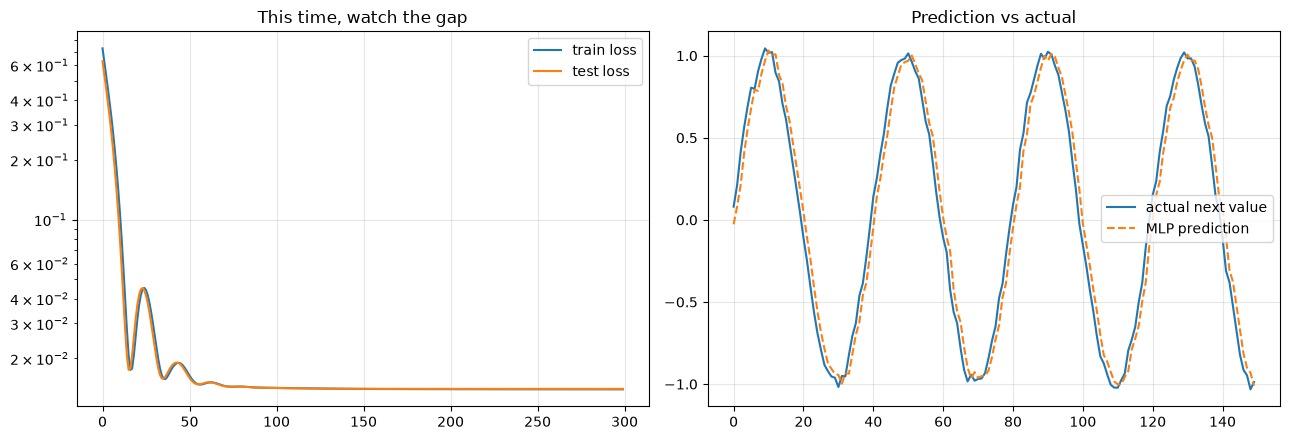

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(train_hist2, label='train loss')
axes[0].plot(test_hist2, label='test loss')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_title('This time, watch the gap')

with torch.no_grad():
    pred_test = model2(Xte).numpy()
show_n = 150
axes[1].plot(y[split:split+show_n], label='actual next value', linewidth=1.5)
axes[1].plot(pred_test[:show_n], label='MLP prediction', linewidth=1.5, linestyle='--')
axes[1].legend(); axes[1].grid(alpha=.3); axes[1].set_title('Prediction vs actual')
plt.tight_layout(); plt.show()

**Look closely at the right-hand plot.** The orange dashed line isn't wrong in a
random way — it's the blue line, shifted one step to the right. The model
learned to do exactly one thing: guess "tomorrow will look like today." Compare
its final test loss to the "just predict no change" number printed above —
they're nearly identical. The network didn't fail to learn. **It learned the
correct answer for the amount of information it was given, and that answer is
persistence.**

**Why, precisely:** the value 0.5 occurs on the way up *and* on the way down —
same input, two different correct next values, depending on which direction the
wave is currently moving. A model that sees only *one point* has no way to
know which. There is no amount of extra training, extra width, or extra depth
that fixes this — the information needed to answer the question was never in
the input to begin with. This is a ceiling set by what the model can *see*, not
by how hard it tried.